In [30]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "Finalterm" / "student-mat.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline


| No. | Variable    | 說明 |
|-----|-------------|------|
| 1   | school      | 就讀學校（GP：Gabriel Pereira；MS：Mousinho da Silveira） |
| 2   | sex         | 性別（F：female；M：male） |
| 3   | age         | 年齡（15–22） |
| 4   | address     | 住家型態（U：urban；R：rural） |
| 5   | famsize     | 家庭人數（LE3：≤3；GT3：>3） |
| 6   | Pstatus     | 父母同住狀態（T：together；A：apart） |
| 7   | Medu        | 母親教育程度（0：none；1：primary；2：5–9th；3：secondary；4：higher） |
| 8   | Fedu        | 父親教育程度（0：none；1：primary；2：5–9th；3：secondary；4：higher） |
| 9   | Mjob        | 母親職業（teacher／health／services／at_home／other） |
| 10  | Fjob        | 父親職業（teacher／health／services／at_home／other） |
| 11  | reason      | 選校原因（home／reputation／course／other） |
| 12  | guardian    | 監護人（mother／father／other） |
| 13  | traveltime  | 通學時間（1：<15min；2：15–30；3：30–60；4：>1hr） |
| 14  | studytime   | 每週讀書時間（1：<2hr；2：2–5；3：5–10；4：>10） |
| 15  | failures    | 過去被當次數（1–3；≥3 記為 4） |
| 16  | schoolsup   | 額外教育輔導（yes／no） |
| 17  | famsup      | 家庭教育支持（yes／no） |
| 18  | paid        | 額外付費課程（yes／no） |
| 19  | activities  | 課外活動（yes／no） |
| 20  | nursery     | 是否上過幼兒園（yes／no） |
| 21  | higher      | 是否想讀高等教育（yes／no） |
| 22  | internet    | 家中是否有網路（yes／no） |
| 23  | romantic    | 是否有戀愛關係（yes／no） |
| 24  | famrel      | 家庭關係品質（1–5） |
| 25  | freetime    | 放學後自由時間（1–5） |
| 26  | goout       | 與朋友外出頻率（1–5） |
| 27  | Dalc        | 工作日酒精攝取（1–5） |
| 28  | Walc        | 週末酒精攝取（1–5） |
| 29  | health      | 健康狀況（1–5） |
| 30  | absences    | 缺課次數（0–93） |
| 31  | G1          | 第一階段成績（0–20） |
| 32  | G2          | 第二階段成績（0–20） |
| 33  | G3          | 最終成績（0–20，預測目標） |


In [31]:
data = pd.read_csv(data_path).rename(columns={'G3':'FinalGrade'})
data = data[data['age'].isin([15, 16, 17, 18])]
# data.loc[data['absences'] >= 4, 'absences'] = 4
print(data['absences'].describe())
x = data['absences']
Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
data = data[(data['absences']>=lower)&(data['absences']<=upper)]
print(data.shape)

count    366.000000
mean       5.382514
std        7.673553
min        0.000000
25%        0.000000
50%        4.000000
75%        8.000000
max       75.000000
Name: absences, dtype: float64
(354, 33)


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 354 entries, 0 to 393
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      354 non-null    object
 1   sex         354 non-null    object
 2   age         354 non-null    int64 
 3   address     354 non-null    object
 4   famsize     354 non-null    object
 5   Pstatus     354 non-null    object
 6   Medu        354 non-null    int64 
 7   Fedu        354 non-null    int64 
 8   Mjob        354 non-null    object
 9   Fjob        354 non-null    object
 10  reason      354 non-null    object
 11  guardian    354 non-null    object
 12  traveltime  354 non-null    int64 
 13  studytime   354 non-null    int64 
 14  failures    354 non-null    int64 
 15  schoolsup   354 non-null    object
 16  famsup      354 non-null    object
 17  paid        354 non-null    object
 18  activities  354 non-null    object
 19  nursery     354 non-null    object
 20  higher      354

In [33]:
# ANOVA 模型
model = smf.ols("FinalGrade ~ C(studytime)", data=data).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                   sum_sq     df         F    PR(>F)
C(studytime)    96.686327    3.0  1.553131  0.200539
Residual      7262.793899  350.0       NaN       NaN


In [34]:
# 類別變項
vars_cat = ["paid", "schoolsup", "famsup", "internet", "activities",  "address"]

# 連續變項
vars_cont  = ['studytime', 'freetime', "goout", "absences", "failures"]

vars = vars_cat + vars_cont

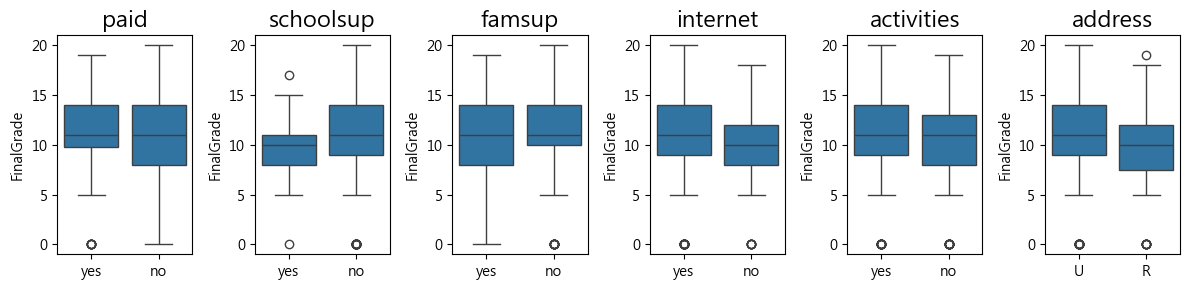

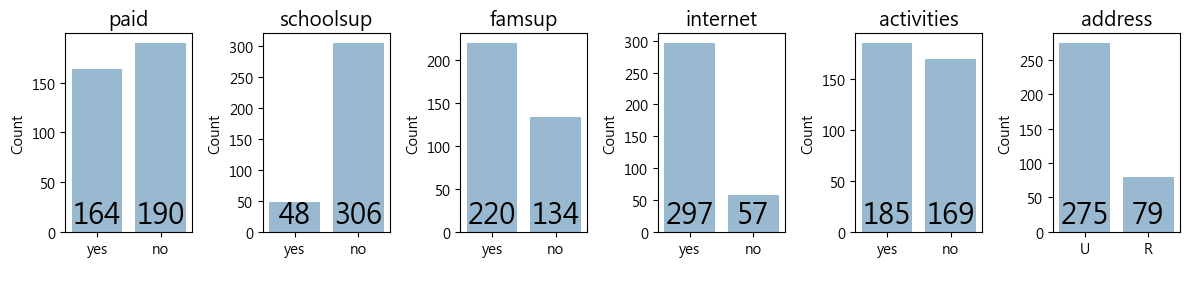

In [35]:
# 類別變項

order_map = {'address': ['U', 'R'],}

default_order = ['yes', 'no']     # 其他全部用 yes/no

plt.figure(figsize=(12, 3))

for i, var in enumerate(vars_cat, 1):
    plt.subplot(1, 6, i)
    order = order_map.get(var, default_order)
    sns.boxplot(x=var, y="FinalGrade", data=data, order=order)
    plt.title(var, fontsize=16)
    plt.xlabel("")
    plt.ylabel("FinalGrade")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))

for i, var in enumerate(vars_cat, 1):
    plt.subplot(1, 6, i)
    order = order_map.get(var, default_order)
    ax = sns.countplot(x=var, data=data, alpha=0.5, order=order)
    plt.title(var, fontsize=14)
    plt.xlabel(" ")
    plt.ylabel("Count")
    # 加上每個 bar 的數字
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,   # x 位置
            2,                          # y 位置
            f"{int(height)}",                # 顯示的文字
            ha="center", va="bottom", fontsize=20
        )
plt.tight_layout()
plt.show()

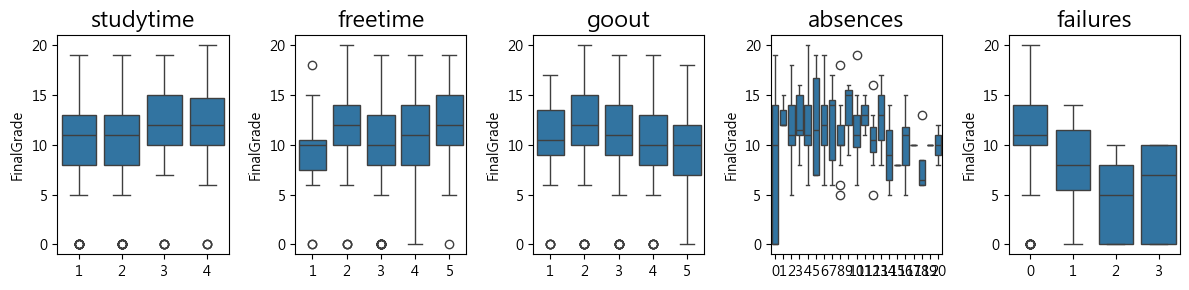

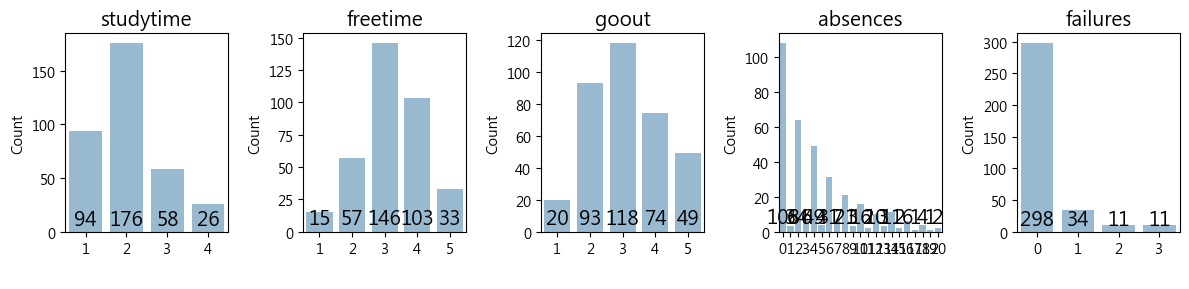

In [36]:
# 連續變項
plt.figure(figsize=(12, 3))
for i, var in enumerate(vars_cont, 1):
    plt.subplot(1, 5, i)
    sns.boxplot(x=var, y="FinalGrade", data=data)
    plt.title(var, fontsize=16)
    plt.xlabel("")
    plt.ylabel("FinalGrade")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))
for i, var in enumerate(vars_cont, 1):
    plt.subplot(1, 5, i)
    ax = sns.countplot(x=var, data=data, alpha=0.5, )
    plt.title(var, fontsize=14)
    plt.xlabel(" ")
    plt.ylabel("Count")
    # 加上每個 bar 的數字
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,   # x 位置
            2,                          # y 位置
            f"{int(height)}",                # 顯示的文字
            ha="center", va="bottom", fontsize=14
        )
plt.tight_layout()
plt.show()

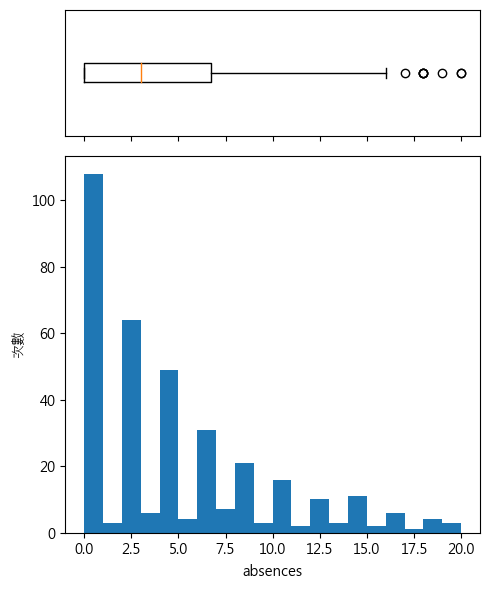

In [37]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(5, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 3]}
)

# Boxplot（上）
axes[0].boxplot(data['absences'], vert=False)
axes[0].set_yticks([])          # 移除 y 軸刻度
axes[0].set_ylabel("")          # 移除 y 軸名稱

# Histogram（下）
axes[1].hist(data['absences'], bins=20)
axes[1].set_xlabel("absences")
axes[1].set_ylabel("次數")

plt.tight_layout()
plt.show()

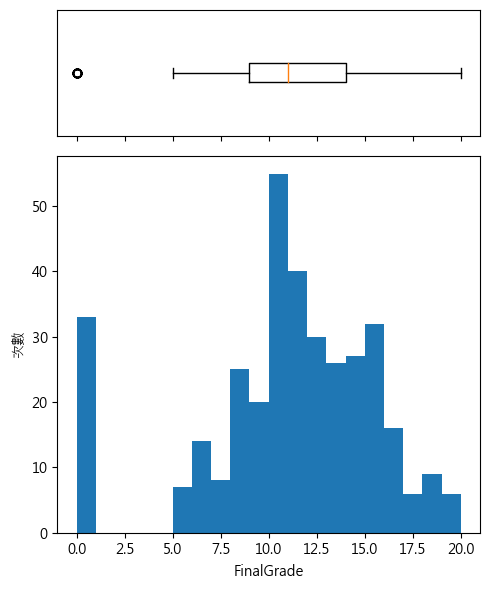

In [38]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(5, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 3]}
)

# Boxplot（上）
axes[0].boxplot(data['FinalGrade'], vert=False)
axes[0].set_yticks([])          # 移除 y 軸刻度
axes[0].set_ylabel("")          # 移除 y 軸名稱

# Histogram（下）
axes[1].hist(data['FinalGrade'], bins=20)
axes[1].set_xlabel("FinalGrade")
axes[1].set_ylabel("次數")

plt.tight_layout()
plt.show()

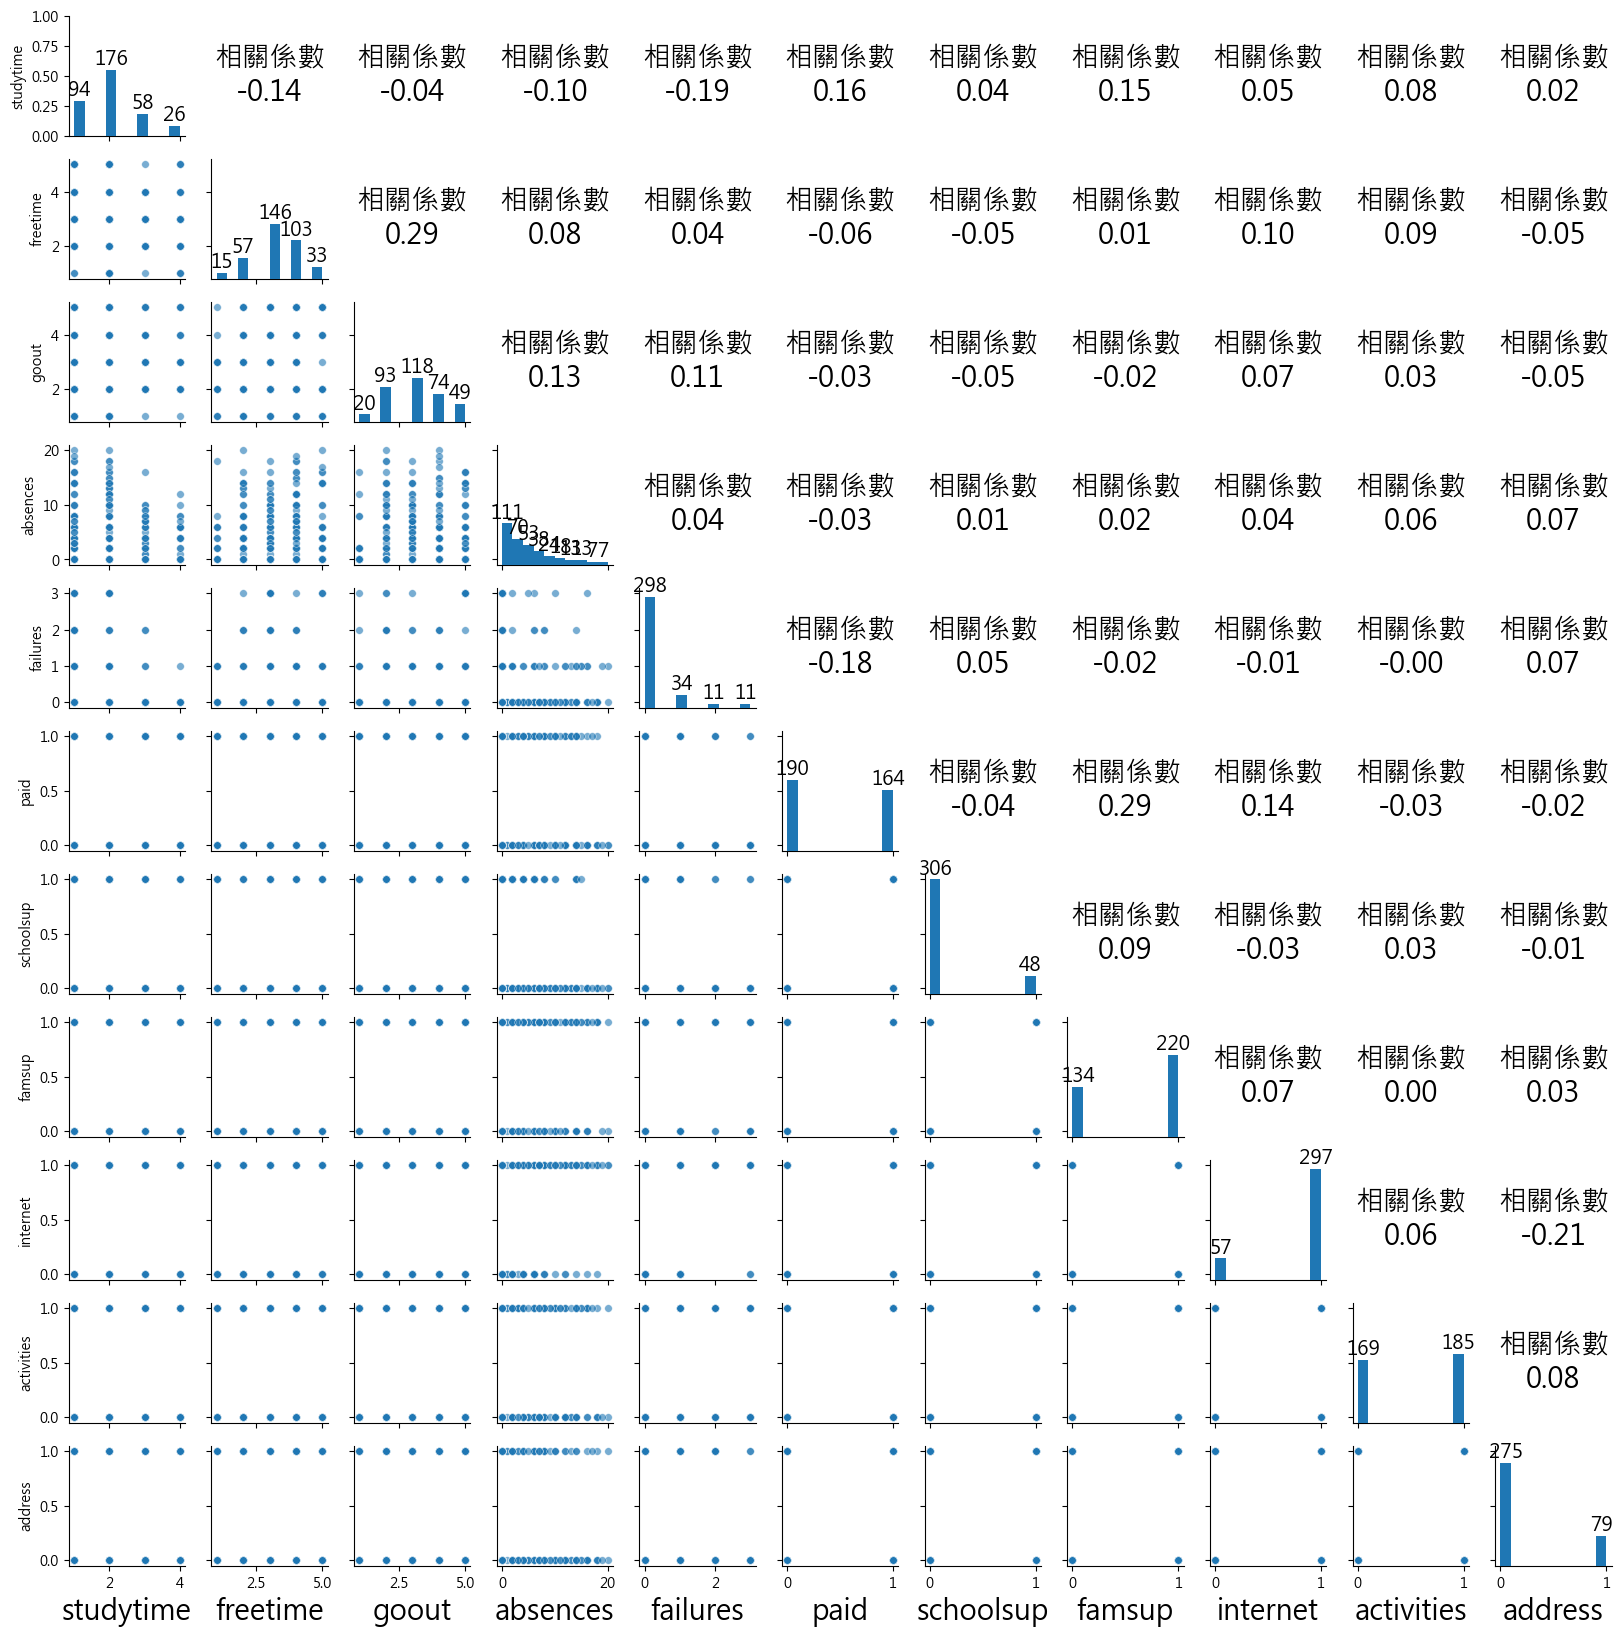

In [39]:
data_bin = data.copy()

for v in vars_cat:
    data_bin[v] = data_bin[v].map({"no": 0, "yes": 1, "U": 0, "R": 1})

# vars_all = vars_cont + vars_cat + ['FinalGrade']
vars_all = vars_cont + vars_cat

def corr_coefficient(x, y, **kws):
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()


    ax.annotate(f"相關係數\n{r:.2f}",
                xy=(0.5, 0.5),
                xycoords=ax.transAxes,
                ha='center', va='center',
                fontsize=20)
    ax.set_axis_off()

def hist_with_counts(x, **kws):
    ax = plt.gca()
    counts, bins, patches = ax.hist(x, bins=10)
    for count, patch in zip(counts, patches):
        if count > 0:
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                count,
                int(count),
                ha='center',
                va='bottom',
                fontsize=14
            )
    for ax in g.axes[-1, :]:
        ax.set_xlabel(ax.get_xlabel(), fontsize=20)

g = sns.PairGrid(data_bin[vars_all], height=1.5, aspect=1.0)
g.map_lower(sns.scatterplot, alpha=0.6, s=30)
g.map_diag(hist_with_counts)
g.map_upper(corr_coefficient)

plt.show()

In [40]:
vars_all.remove('freetime')

In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = data_bin[vars_all].dropna().copy()

vif_df = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])]
})

vif_df.sort_values('VIF', ascending=False)

,variable,VIF
1,goout,6.269246
0,studytime,5.732847
7,internet,5.575474
6,famsup,2.914217
4,paid,2.167620
8,activities,2.121905
2,absences,1.911809
9,address,1.332072
3,failures,1.235476
5,schoolsup,1.172497


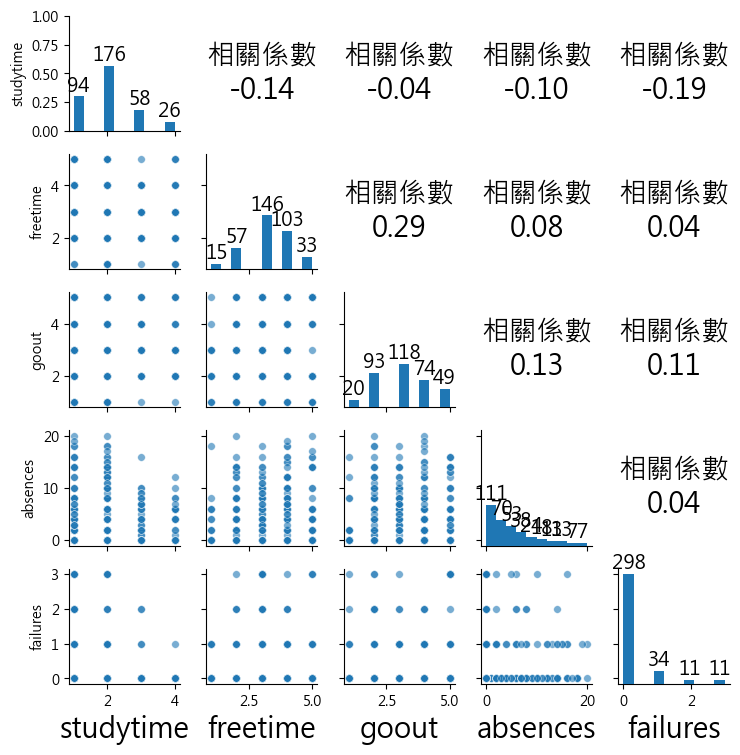

In [13]:
vars_pair = vars_cont + ['FinalGrade']

def corr_coefficient(x, y, **kws):
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()


    ax.annotate(f"相關係數\n{r:.2f}",
                xy=(0.5, 0.5),
                xycoords=ax.transAxes,
                ha='center', va='center',
                fontsize=20)
    ax.set_axis_off()

def hist_with_counts(x, **kws):
    ax = plt.gca()
    counts, bins, patches = ax.hist(x, bins=10)
    for count, patch in zip(counts, patches):
        if count > 0:
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                count,
                int(count),
                ha='center',
                va='bottom',
                fontsize=14
            )
    for ax in g.axes[-1, :]:
        ax.set_xlabel(ax.get_xlabel(), fontsize=20)

g = sns.PairGrid(data[vars_cont], height=1.5, aspect=1.0)
g.map_lower(sns.scatterplot, alpha=0.6, s=30)
g.map_diag(hist_with_counts)
g.map_upper(corr_coefficient)

plt.show()

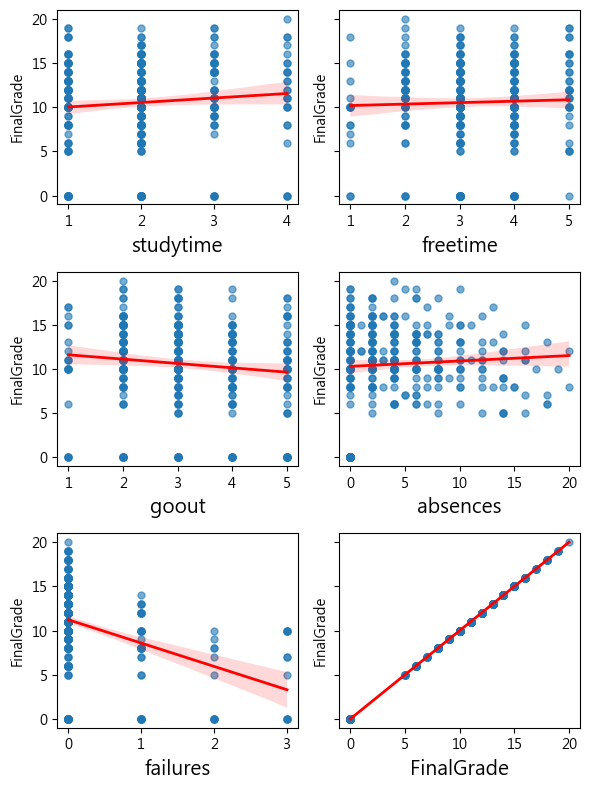

In [14]:
y = 'FinalGrade'
n = len(vars_pair)
fig, axes = plt.subplots(3, 2, figsize=(6, 8), sharey=True)

axes = axes.flatten()
for ax, v in zip(axes, vars_pair):
    sns.regplot(
        x=v, y=y, data=data,
        ax=ax,
        scatter_kws={"alpha": 0.6, "s": 25},
        line_kws={"color": "red", "linewidth": 2}
    )
    ax.set_xlabel(v, fontsize=14)

axes[0].set_ylabel("FinalGrade", fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
y = "FinalGrade"
results = []

def fit_simple_ols(df, y_col, x_series, x_name, x_type):
    y = pd.to_numeric(df[y_col], errors="coerce")
    x = pd.to_numeric(x_series, errors="coerce")

    tmp = pd.DataFrame({"y": y, "x": x})
    if tmp.shape[0] < 3:
        return None
    if tmp["x"].nunique() < 2:
        return None

    # 強制轉 float，避免 object dtype
    y_np = np.asarray(tmp["y"], dtype=float)
    X_np = sm.add_constant(np.asarray(tmp["x"], dtype=float))

    model = sm.OLS(y_np, X_np).fit()

    # 係數順序：[const, x]
    beta = model.params[1]
    tval = model.tvalues[1]
    pval = model.pvalues[1]

    return {
        "variable": x_name,
        "beta": beta,
        "t": tval,
        "p_value": pval,
    }

# 連續變項
for var in vars_cont:
    output = fit_simple_ols(data, "FinalGrade", data[var], var, "continuous")
    results.append(output)

# 類別變項
for var in vars_cat:
    dummies = pd.get_dummies(data[var], prefix=var, drop_first=True)
    for col in dummies.columns:
        output = fit_simple_ols(data, "FinalGrade", dummies[col], col, "categorical_dummy")
        results.append(output)

result_df = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)
print(result_df[["variable","beta","t","p_value"]])

          variable      beta         t       p_value
0         failures -2.640444 -7.772439  8.550916e-14
1            goout -0.491433 -2.267494  2.396580e-02
2         paid_yes  0.956547  1.973516  4.921861e-02
3     internet_yes  1.203615  1.828956  6.825214e-02
4        address_U  1.054914  1.815798  7.025208e-02
5    schoolsup_yes -1.267157 -1.793216  7.379679e-02
6        studytime  0.509804  1.789466  7.439934e-02
7       famsup_yes -0.646133 -1.292588  1.970015e-01
8         absences  0.061055  1.197485  2.319234e-01
9         freetime  0.163958  0.654742  5.130618e-01
10  activities_yes  0.210267  0.432277  6.658050e-01


In [16]:
y = "FinalGrade"
results = []
# 類別變項：one-way ANOVA（F, p-value）
vars_cat = ["paid", "schoolsup", "famsup", "internet", "activities", "address"]
for v in vars_cat:
    model = smf.ols(f"{y} ~ C({v})", data=data).fit()
    aov = anova_lm(model, typ=2)
    results.append({
        "variable": v,
        "stat": "F",
        "value": aov.loc[f"C({v})", "F"],
        "p_value": aov.loc[f"C({v})", "PR(>F)"]
    })

# 連續變項：simple linear regression（t, p-value）
vars_cont = ['studytime', 'freetime', 'goout', 'absences', 'failures']
for v in vars_cont:
    model = smf.ols(f"{y} ~ {v}", data=data).fit()
    results.append({
        "variable": v,
        "stat": "t",
        "value": model.tvalues[v],
        "p_value": model.pvalues[v],
        'beta':model.params[v]
    })

anova_table = pd.DataFrame(results)
print(anova_table)

      variable stat     value       p_value      beta
0         paid    F  3.894764  4.921861e-02       NaN
1    schoolsup    F  3.215623  7.379679e-02       NaN
2       famsup    F  1.670783  1.970015e-01       NaN
3     internet    F  3.345080  6.825214e-02       NaN
4   activities    F  0.186863  6.658050e-01       NaN
5      address    F  3.297121  7.025208e-02       NaN
6    studytime    t  1.789466  7.439934e-02  0.509804
7     freetime    t  0.654742  5.130618e-01  0.163958
8        goout    t -2.267494  2.396580e-02 -0.491433
9     absences    t  1.197485  2.319234e-01  0.061055
10    failures    t -7.772439  8.550916e-14 -2.640444


In [42]:
# 類別變項
vars_cat = ["paid", "schoolsup", "famsup", "internet", "activities",  "address"]
# 連續變項
vars_cont  = ['studytime', "goout", "absences", "failures"]
# 建立 formula
terms = []
for v in vars_cat:
    terms.append(f"C({v})")
for v in vars_cont:
    terms.append(v)

formula_model = "FinalGrade ~ " + " + ".join(terms)

print("Model formula：")
print(formula_model)

# 擬合模型
model = smf.ols(formula_model, data=data).fit()
print(model.summary())

Model formula：
FinalGrade ~ C(paid) + C(schoolsup) + C(famsup) + C(internet) + C(activities) + C(address) + studytime + goout + absences + failures
                            OLS Regression Results                            
Dep. Variable:             FinalGrade   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.167
Method:                 Least Squares   F-statistic:                     8.075
Date:                Sat, 13 Dec 2025   Prob (F-statistic):           1.00e-11
Time:                        20:07:48   Log-Likelihood:                -1002.0
No. Observations:                 354   AIC:                             2026.
Df Residuals:                     343   BIC:                             2069.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|

In [34]:
R2 = model.rsquared
Adj_R2 = model.rsquared_adj
F_stat = model.fvalue
F_p = model.f_pvalue

R2, Adj_R2, F_stat, F_p


(0.1951780413558828,
 0.16929195496674454,
 7.539882175382796,
 1.231922455198019e-11)

In [43]:
coef_table = pd.DataFrame({
    "variable": model.params.index,
    "coef": model.params.values,
    "p_value": model.pvalues.values
})

coef_table.sort_values('p_value', ascending=True)

,variable,coef,p_value
0,Intercept,10.709843,1.288303e-20
10,failures,-2.424856,2.116963e-11
8,goout,-0.437920,3.191182e-02
9,absences,0.095259,4.579310e-02
3,C(famsup)[T.yes],-0.910717,6.095701e-02
4,C(internet)[T.yes],0.972216,1.226099e-01
2,C(schoolsup)[T.yes],-0.998442,1.277770e-01
6,C(address)[T.U],0.727600,1.878860e-01
1,C(paid)[T.yes],0.437589,3.624948e-01
7,studytime,0.204278,4.543762e-01


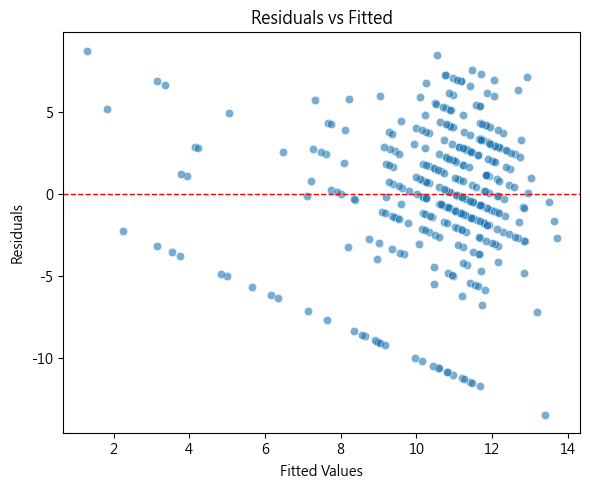

<Figure size 600x500 with 0 Axes>

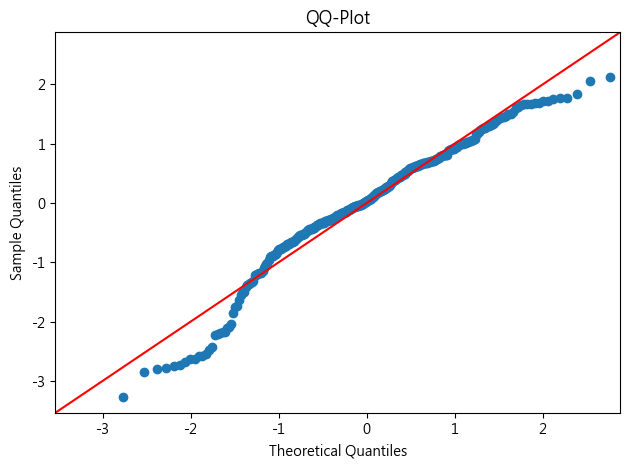

In [44]:
# 取得殘差與預測值
residuals = model.resid
fitted = model.fittedvalues

# -----------------------------
# 1. Residuals vs Fitted Scatter
# -----------------------------
plt.figure(figsize=(6,5))
sns.scatterplot(x=fitted, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

# -----------------------------
# 2. QQ Plot（檢查殘差常態性）
# -----------------------------
plt.figure(figsize=(6,5))
sm.qqplot(residuals, line='45', fit=True)
plt.title("QQ-Plot")
plt.tight_layout()
plt.show()

In [45]:
from scipy.stats import shapiro

shapiro(residuals)

ShapiroResult(statistic=0.961235761642456, pvalue=4.565040967463574e-08)

In [49]:


from statsmodels.stats.diagnostic import het_breuschpagan

exog = model.model.exog   # 設計矩陣（含 dummy）

bp_test = het_breuschpagan(residuals, exog)

bp_results = {
    "LM statistic": bp_test[0],
    "LM p-value": bp_test[1],
    "F statistic": bp_test[2],
    "F p-value": bp_test[3]
}

bp_results

{'LM statistic': 31.412084304358057,
 'LM p-value': 0.0005014771739195564,
 'F statistic': 3.3399716456087867,
 'F p-value': 0.0003652148759858291}

In [50]:
model_robust = model.get_robustcov_results(cov_type="HC3")
print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:             FinalGrade   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.167
Method:                 Least Squares   F-statistic:                     5.996
Date:                Sat, 13 Dec 2025   Prob (F-statistic):           2.15e-08
Time:                        21:42:27   Log-Likelihood:                -1002.0
No. Observations:                 354   AIC:                             2026.
Df Residuals:                     343   BIC:                             2069.
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               10.7098 

In [51]:
exog_r =  model_robust.model.exog   # 設計矩陣（含 dummy）
resi = model_robust.resid
bp_test = het_breuschpagan(resi, exog_r)

bp_results = {
    "LM statistic": bp_test[0],
    "LM p-value": bp_test[1],
    "F statistic": bp_test[2],
    "F p-value": bp_test[3]
}

bp_results

{'LM statistic': 31.412084304358057,
 'LM p-value': 0.0005014771739195564,
 'F statistic': 3.3399716456087867,
 'F p-value': 0.0003652148759858291}

In [47]:
from statsmodels.stats.stattools import durbin_watson
durbin_watson(residuals)

1.9636284278736915

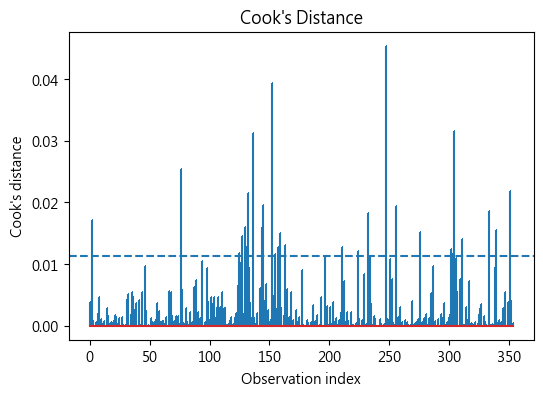

In [48]:
influence = model.get_influence()
cooks = influence.cooks_distance[0]

plt.figure(figsize=(6, 4))
plt.stem(cooks, markerfmt=",")
plt.axhline(4 / len(cooks), linestyle="--")
plt.xlabel("Observation index")
plt.ylabel("Cook's distance")
plt.title("Cook's Distance")
plt.show()